In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [2]:
f1 = open("data_02.txt", "r")
f2 = open("data_04.txt", "r")
#f3 = open("data_06.txt", "r")
f3 = open("runlog", "r")

In [3]:
steps1, a1, phi1, dphi1 = [], [], [], []
steps2, a2, phi2, dphi2 = [], [], [], []
steps3, a3, phi3, dphi3 = [], [], [], []

In [4]:
f1.readline()
for line in f1.readlines():
    fields = line.split()
    steps1.append( float(fields[0]))
    a1.append(     float(fields[3]))
    phi1.append(   float(fields[6]))
    dphi1.append(  float(fields[7]))
f2.readline()
for line in f2.readlines():
    fields = line.split()
    steps2.append( float(fields[0]))
    a2.append(     float(fields[3]))
    phi2.append(   float(fields[6]))
    dphi2.append(  float(fields[7]))
f3.readline()
for line in f3.readlines():
    fields = line.split()
    steps3.append( float(fields[0]))
    a3.append(     float(fields[3]))
    phi3.append(   float(fields[7])) # N.B. For new runlogs, phi and dphi are 7 and 8 resp., since I've added e-folds to the output.
    dphi3.append(  float(fields[8]))

In [5]:
f1.close()
f2.close()
f3.close()

In [6]:
#phi3

In [7]:
mass = 0.03

In [8]:
# Maybe the squared \dot{\phi} equation would be easier?
def sys(t, y, m):
    ph   = y[0]
    dph  = y[1]
    
    Ddph = -np.sqrt(12.*np.pi*(dph*dph + m*m*ph*ph))*dph - m*m*ph
    Dph  = dph
    
    return [Dph, Ddph]

In [9]:
t_eval = np.linspace(0., 300, 3000)
y0     = [1.2, -mass/np.sqrt(12.*np.pi)] 

In [10]:
y0

[1.2, -0.004886025119029199]

In [11]:
sol = solve_ivp(sys, [0, 300], y0, vectorized=True, dense_output=True, t_eval=t_eval, args = [mass])

In [12]:
yvals = sol.sol(t_eval)

In [13]:
#sol

Text(0, 0.5, '$\\dot{\\phi}$')

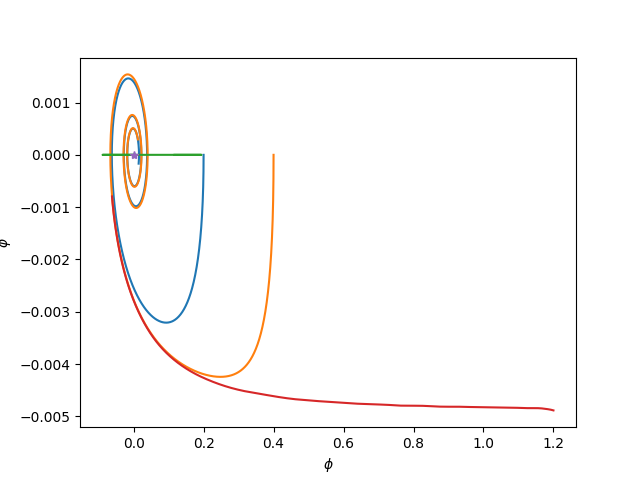

In [16]:
#%matplotlib ipympl
%matplotlib widget
plt.plot(phi1,dphi1)
plt.plot(phi2,dphi2)
plt.plot(phi3,dphi3)
#plt.plot(xrange,yrange)
plt.plot(sol.y[0,:], sol.y[1,:])
plt.plot([0.],[0.], marker = "*")
plt.xlabel("$\phi$")
plt.ylabel("$\dot{\phi}$")

[]

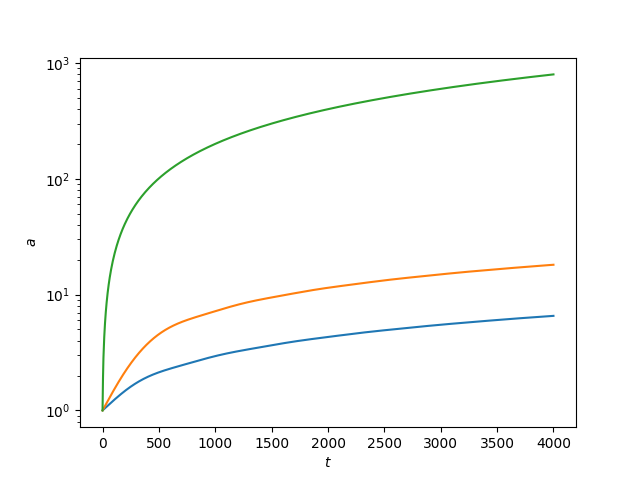

In [15]:
%matplotlib widget
plt.plot(steps1,a1)
plt.plot(steps2,a2)
plt.plot(steps3,a3)
plt.xlabel("$t$")
plt.ylabel("$a$")
plt.semilogy()